In [1]:
import matplotlib as mpl

new_rc_params = {'text.usetex': False,
                 "svg.fonttype": 'none'
                }

mpl.rcParams.update(new_rc_params)
import matplotlib.cm as cm

In [2]:
import sys, os
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

import pre_functions_clean as pf
import time_constant_shuffle_FLN as tc
import Time_Constant_Plot as TCP

In [3]:
# Read Experiment Data
filepath_lst = ['Data/Marmoset_Ji/Ji20180313S3c/',
                'Data/Marmoset_Ji/Ji20180317S3c/',
                'Data/Marmoset_Ji/Ji20180313S5c/',
                'Data/Marmoset_Ji/Ji20180308S15c/']

# filepath_lst = ['Data/Marmoset_Ji/Ji20180308S3c/',
#                 'Data/Marmoset_Ji/Ji20180313S3c/',
#                 'Data/Marmoset_Ji/Ji20180317S3c/',
#                 'Data/Marmoset_Ji/Ji20180324S3c/',
#                 'Data/Marmoset_Ji/Ji20180308S5c/',
#                 'Data/Marmoset_Ji/Ji20180313S5c/',
#                 'Data/Marmoset_Ji/Ji20180317S5c/',
#                 'Data/Marmoset_Ji/Ji20180324S5c/',
#                 'Data/Marmoset_Ji/Ji20180308S15c/',
#                 'Data/Marmoset_Ji/Ji20180313S15c/',
#                 'Data/Marmoset_Ji/Ji20180317S15c/',
#                 'Data/Marmoset_Ji/Ji20180324S15c/']

area_map_path = 'Data/Marmoset_Ji/ElectrodesIndexJi.csv'

channel_num = 96

# Ji

t_start = [17771, 9990, 11262, 22957]

# t_start = [5912, 17771, 9990, 6157,
#             6061, 11262, 5004, 7660,
#             22957, 5933, 5063, 4891]

In [4]:
# Read Model Data
MACAQUE_CASE=0
CONSENSUS_CASE=0
datafile='subgraph_data_marmoset.pkl'
p = pf.load_data(datafile)
p,W = pf.genetate_net_connectivity(p,LINEAR_HIER=0,FIT_HIER=1, IDENTICAL_HIER=0,LOCAL_IDENTICAL_HIERARCHY=0,ZERO_FLN=0,
                                   IDENTICAL_FLN=0,SHUFFLE_FLN=0,SHUFFLE_TYPE=0,STRONG_GBA=0,
                                   MACAQUE_CASE=MACAQUE_CASE,GATING_PATHWAY=0,LONGRANGE_EI_ASYMMETRY=0,CONSENSUS_CASE=CONSENSUS_CASE,
                                   diverse_hi=41)

df = pd.read_excel('Data/Marmoset_Model/Area_map_Marmoset_W.xlsx')
Area_dict = dict(zip(df['Area'], df['Region']))

AOI = ['V1', 'V2', 'V6', 'V3A', 'V4',
       'TE3', 'A47L', 'A8b']

# AOI = ['V1', 'V2', 'V6',
#        'TE3', 'A47L', 'A8b']

spine_count_AOI = [1000, 1100, 1200, 1600, 2100,
                   3100, 3600, 4900]

Initializing Model. From subgraph_data_marmoset.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
CONSENSUS_CASE=0
No STRONG GBA


In [5]:
# Compute Time constant
ind = np.arange(len(t_start))
# ind = np.arange(0, 12)
# ind = [2, 5]
filepath_lst = np.array(filepath_lst)[ind]
t_start = np.array(t_start)[ind]

psds_avg = 0
acf_avg = 0; nlags = 300
for k in range(len(filepath_lst)):
    file_path = filepath_lst[k]
    channel_all = []
    for i in range(1, channel_num+1):
        if os.path.exists(file_path+'ECoG_ch{}.mat'.format(i)):
            data_i = scipy.io.loadmat(file_path+'ECoG_ch{}.mat'.format(i))
            channel_i = data_i['ECoGData'].reshape([-1])
            channel_all.append(channel_i)
    channel_all = np.array(channel_all)
    
    channel_eff = channel_all[:, 2000 : int(np.floor(t_start[k]/1000)*1000)]
    # channel_eff = channel_all[:, 1000:6000]
    acf_eff = TCP.compute_acf_matrix(channel_eff, nlags=nlags)
    f_axis, psds_reg = TCP.compute_psds(channel_eff, fs=1000.)
    
    psds_avg += psds_reg
    acf_avg += acf_eff

psds_avg /= len(filepath_lst)
acf_avg /= len(filepath_lst)

df = pd.read_csv(area_map_path)
Area = np.array(df['area_abb'])
# Area = np.delete(Area, [5,6, 7, 96, 97], axis=0)
Area_set = np.unique(Area)
area = np.array([i for i in Area_set if i in p['areas']])
region = np.array([Area_dict[i] for i in area])
acf_mat = np.zeros([len(area), nlags+1])

tau_lst_exp = [0] * len(area)
fok_lst_exp = [0] * len(area)
for i in range(len(area)):
    psds_i = np.mean(psds_avg[Area == area[i], :], axis=0)
    acf_i = np.mean(acf_avg[Area == area[i], :], axis=0)
    acf_mat[i, :] = acf_i
    tau, fok = TCP.compute_tau(f_axis, psds_i)
    tau_lst_exp[i] = tau
    fok_lst_exp[i] = fok

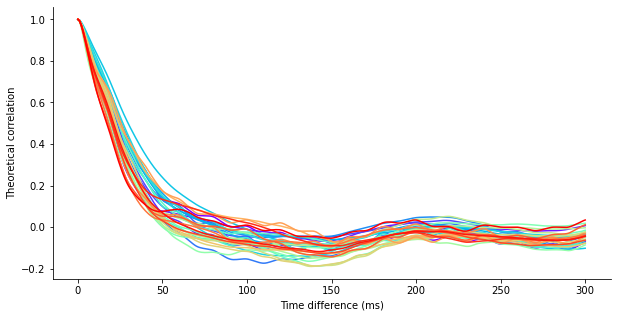

In [6]:
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, len(area)))[np.newaxis, :, :3]

plt.figure(figsize=(10,5))
ax = plt.axes()
for i in np.arange(len(area)):
    plt.plot(np.arange(nlags+1),acf_mat[i,:],color=clist[0][i])

# plt.legend(area)
plt.xlabel('Time difference (ms)')
plt.ylabel('Theoretical correlation')
# plt.title('input_loc='+input_loc)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [7]:
Area_set

array(['A1/2', 'A10', 'A19DI', 'A3a', 'A3b', 'A46D', 'A47L', 'A47M',
       'A4ab', 'A6DR', 'A6Va', 'A6Vb', 'A8aD', 'A8aV', 'A8b', 'A9',
       'AuA1', 'AuAL', 'AuCL', 'AuML', 'AuR', 'AuRPB', 'AuRTL', 'FST',
       'LIP', 'MIP', 'MST', 'OPt', 'PE', 'PF', 'PFG', 'PG', 'ProM', 'S2E',
       'S2PR', 'STR', 'TE1', 'TE3', 'TPO', 'TPt', 'V1', 'V2', 'V3', 'V3A',
       'V4', 'V4T', 'V5', 'V6'], dtype=object)

In [8]:
len(area)

33

In [9]:
expon_lst_exp = [0] * len(area)
for i in range(len(area)):
    expon_lst_exp[i] = fok_lst_exp[i].get_results()[0][2]

# Awake Data

In [10]:
# Read Experiment Data

filepath_lst = ['Data/Marmoset_Hn/']

area_map_path = 'Data/Marmoset_Hn/Area_map_Marmoset_H.csv'

channel_num = 64

# Ji

# t_start = [17771, 9990, 11262, 22957]

t_start = np.array([6782])

In [11]:
# Compute Time constant
ind = np.arange(len(t_start))
# ind = np.arange(0, 12)
# ind = [2, 5]
filepath_lst = np.array(filepath_lst)[ind]
t_start = np.array(t_start)[ind]

psds_avg = 0
acf_avg = 0; nlags = 300
for k in range(len(filepath_lst)):
    file_path = filepath_lst[k]
    channel_all = []
    for i in range(1, channel_num+1):
        if os.path.exists(file_path+'ECoG_ch{}.mat'.format(i)):
            data_i = scipy.io.loadmat(file_path+'ECoG_ch{}.mat'.format(i))
            channel_i = data_i['ECoGData_ch{}'.format(i)].reshape([-1])
            channel_all.append(channel_i)
    channel_all = np.array(channel_all)
    
    channel_eff = channel_all[:, 2000 : int(np.floor(t_start[k]/1000)*1000)]
    # channel_eff = channel_all[:, 1000:6000]
    acf_eff = TCP.compute_acf_matrix(channel_eff, nlags=nlags)
    f_axis, psds_reg = TCP.compute_psds(channel_eff, fs=1000.)
    
    psds_avg += psds_reg
    acf_avg += acf_eff

psds_avg /= len(filepath_lst)
acf_avg /= len(filepath_lst)

df = pd.read_csv(area_map_path)
Area_awake = np.array(df['area_abb'])
# Area = np.delete(Area, [6,7,8], axis=0)
Area_set_awake = np.unique(Area_awake)
area_awake = np.array([i for i in Area_set_awake if i in p['areas']])
region_awake = np.array([Area_dict[i] for i in area_awake])

tau_lst_exp_awake = [0] * len(area_awake)
fok_lst_exp_awake = [0] * len(area_awake)
acf_mat = np.zeros([len(area_awake), nlags+1])

for i in range(len(area_awake)):
    psds_i = np.median(psds_avg[Area_awake == area_awake[i], :], axis=0)
    acf_i = np.mean(acf_avg[Area_awake == area_awake[i], :], axis=0)
    acf_mat[i, :] = acf_i
    tau, fok = TCP.compute_tau(f_axis, psds_i,max_n_peaks=2, fit_range=[0,100])
    tau_lst_exp_awake[i] = tau
    fok_lst_exp_awake[i] = fok

In [12]:
channel_all.shape

(64, 905277)

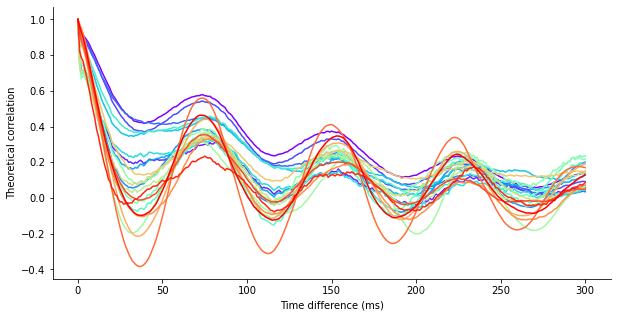

In [13]:
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, len(area_awake)))[np.newaxis, :, :3]

plt.figure(figsize=(10,5))
ax = plt.axes()
for i in np.arange(len(area_awake)):
    plt.plot(np.arange(nlags+1),acf_mat[i,:],color=clist[0][i])

# plt.legend(area)
plt.xlabel('Time difference (ms)')
plt.ylabel('Theoretical correlation')
# plt.title('input_loc='+input_loc)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [14]:
Area_set_awake

array(['A1/2', 'A10', 'A45', 'A46D', 'A47L', 'A4ab', 'A4c', 'A6M', 'A8aV',
       'A8b', 'AuA1', 'AuML', 'AuRT', 'DI', 'GI', 'PE', 'PFG', 'S2E',
       'TE3', 'Unknown', 'V1', 'V2', 'V3A', 'V4', 'V5', 'V6'],
      dtype=object)

In [15]:
len(area_awake)

22

In [16]:
expon_lst_exp_awake = [0] * len(area_awake)
freq_lst_exp_awake = [0] * len(area_awake)
for i in range(len(area_awake)):
    expon_lst_exp_awake[i] = fok_lst_exp_awake[i].get_results()[0][2]
    freq_lst_exp_awake[i] = fok_lst_exp_awake[i].get_results()[0][1]

In [17]:
i = 0
freq_lst_exp_awake[i]**(1./expon_lst_exp_awake[i])

3.9703305154947426

# Fig.1B Illustration of the recovery ot timescale

## An example fit of PSD

## Histogram of exponent close to 2

(array([ 0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 0, '')])

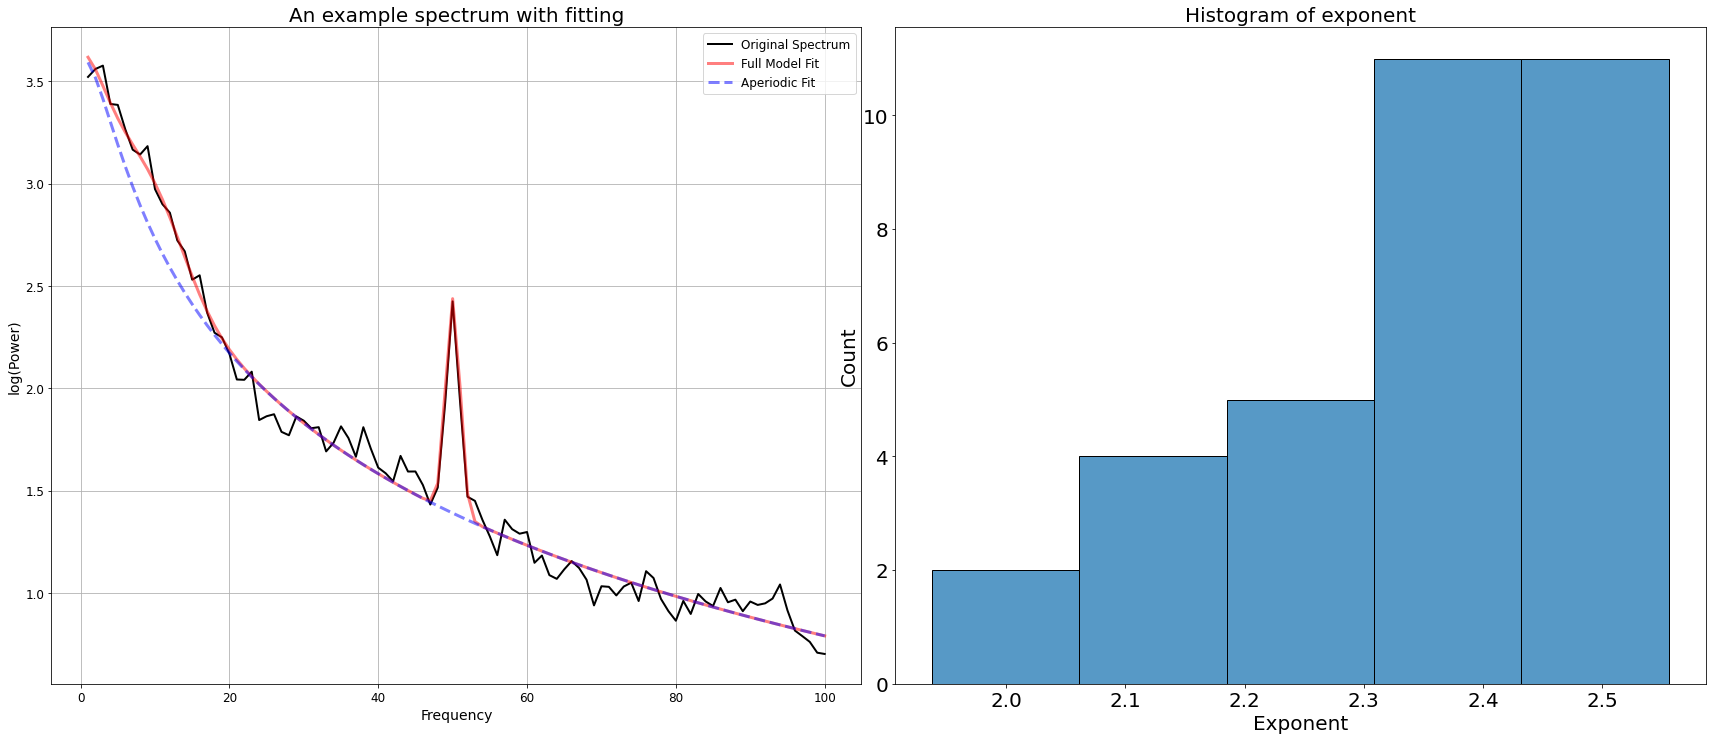

In [18]:
fig, ax = plt.subplots(1,2,figsize=(24, 10), facecolor=(1, 1, 1))

fok_lst_exp[0].plot(ax = ax[0]); # ax[0].set_xscale('log')
ax[0].set_title('An example spectrum with fitting', fontsize=20)

f1=sns.histplot(expon_lst_exp, ax=ax[1], bins=5)
ax[1].set_title('Histogram of exponent', fontsize=20)
ax[1].set_xlabel('Exponent', fontsize=20)
ax[1].set_ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.xlim([1.5, 3])
# TCP.save_fig('Figures/1B')

In [19]:
# Data Alignment between Exp & Model
hi_exp = np.zeros([len(area),])
for i in range(len(area)):
    hi_exp[i] = p['hier_vals'][p['areas'].index(area[i])]
    
area_sort = []
for area_k in p['areas']:
    if area_k in area:
        area_sort.append(area_k)

(array([0., 1., 2., 3., 4., 5., 6., 7., 8.]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

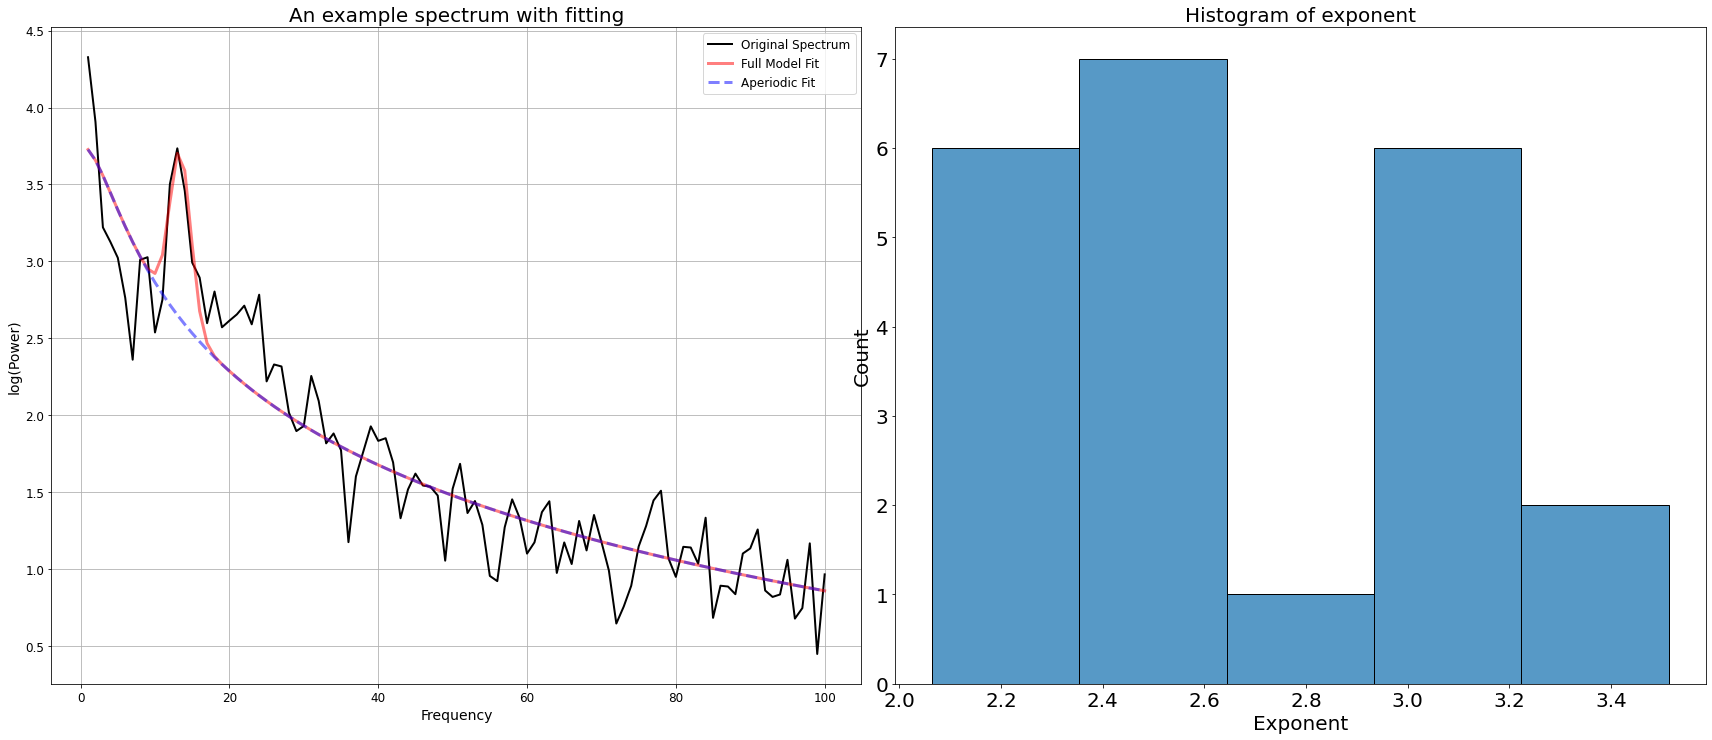

In [20]:
fig, ax = plt.subplots(1,2,figsize=(24, 10), facecolor=(1, 1, 1))

fok_lst_exp_awake[0].plot(ax = ax[0]); # ax[0].set_xscale('log')
ax[0].set_title('An example spectrum with fitting', fontsize=20)

f1=sns.histplot(expon_lst_exp_awake, ax=ax[1], bins=5)
ax[1].set_title('Histogram of exponent', fontsize=20)
ax[1].set_xlabel('Exponent', fontsize=20)
ax[1].set_ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.xlim([1.5, 3])
# TCP.save_fig('Figures/1B')

In [21]:
# Data Alignment between Exp & Model
hi_exp_awake = np.zeros([len(area_awake),])
for i in range(len(area_awake)):
    hi_exp_awake[i] = p['hier_vals'][p['areas'].index(area_awake[i])]
    
area_sort_awake = []
for area_k in p['areas']:
    if area_k in area_awake:
        area_sort_awake.append(area_k)

In [22]:
# fok_lst_exp_awake[11].report()

# Fig.1C Visualization of the observed timescale gradient across the whole brain.

(10.0, 50.0)

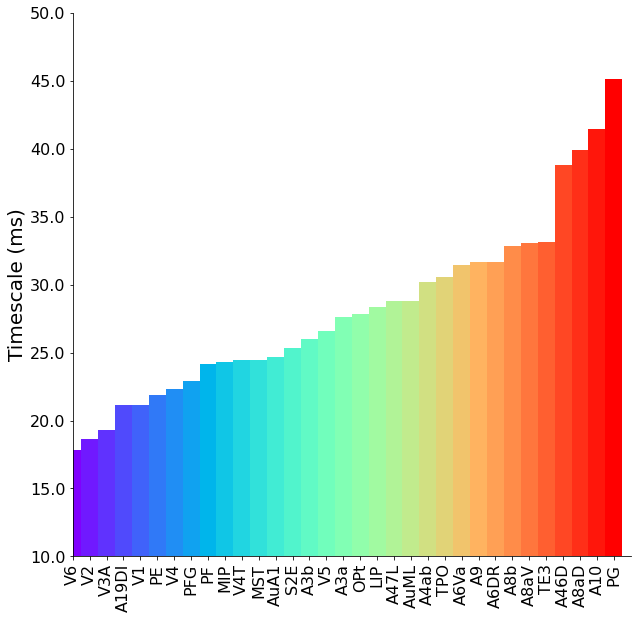

In [23]:
fig, ax=plt.subplots(figsize=(10,10), facecolor=(1, 1, 1))
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, len(area)))[np.newaxis, :, :3]
sort_ind = np.argsort(tau_lst_exp)
# sort_ind = np.argsort(hi_exp)
area_sort = area[sort_ind]
ax.bar(np.arange(len(area)), np.array(tau_lst_exp)[sort_ind],width = 1,color=clist[0])
ax.set_xticks(np.arange(len(area)))
ax.set_yticks(np.linspace(10, 50, 9))
ax.set_yticklabels(np.linspace(10, 50, 9),fontsize=16)
ax.set_xticklabels(area_sort ,rotation=90,fontsize=16)
# plt.yticks([10,100,1000],['10 ms','100 ms','1 s'],rotation=0)
ax.set_ylabel('Timescale (ms)',fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim((0, len(area)))
ax.set_ylim((10, 50))
# TCP.save_fig('Figures/1C')

(0.0, 45.0)

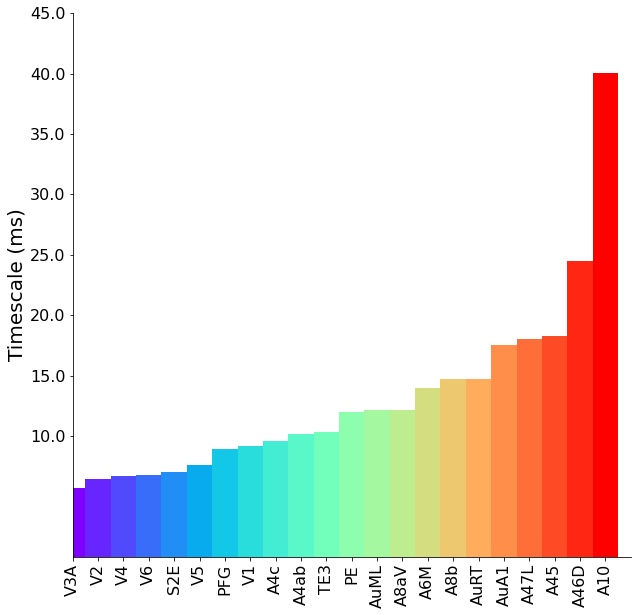

In [24]:
fig, ax=plt.subplots(figsize=(10,10), facecolor=(1, 1, 1))
clist = cm.get_cmap(plt.get_cmap('rainbow'))(np.linspace(0.0, 1.0, len(area_awake)))[np.newaxis, :, :3]
sort_ind = np.argsort(tau_lst_exp_awake)
# sort_ind = np.argsort(hi_exp_awake)
area_sort_awake = area_awake[sort_ind]
ax.bar(np.arange(len(area_awake)), np.array(tau_lst_exp_awake)[sort_ind],width = 1,color=clist[0])
ax.set_xticks(np.arange(len(area_awake)))
ax.set_yticks(np.linspace(10, 50, 9))
ax.set_yticklabels(np.linspace(10, 50, 9),fontsize=16)
ax.set_xticklabels(area_sort_awake ,rotation=90,fontsize=16)
# plt.yticks([10,100,1000],['10 ms','100 ms','1 s'],rotation=0)
ax.set_ylabel('Timescale (ms)',fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim((0, len(area_awake)))
ax.set_ylim((0, 45))
# TCP.save_fig('Figures/1C_awake')

## Compare the timescale between awake and ketamin

In [25]:
area_plot, index_exp, index_awake = np.intersect1d(area, area_awake, return_indices=True)

(10.0, 50.0)

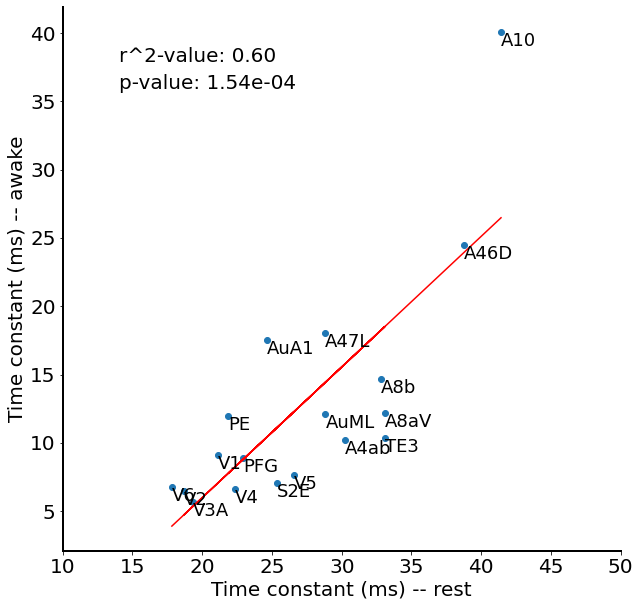

In [26]:
# Fig. Tau vs hi (experiment data)
fig = TCP.plot_tau_feature(np.array(tau_lst_exp_awake)[index_awake], np.array(tau_lst_exp)[index_exp], area_plot,
        x_label='Time constant (ms) -- rest', y_label='Time constant (ms) -- awake',
        annotate_flag=True, log_flag=False)
fig.set_figwidth(10)
plt.xlim([10, 50])
# TCP.save_fig('Figures/1C_cmp_awake_ketamin')

# Change to rainbow color bar later

In [27]:
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(np.array(tau_lst_exp)[index_exp], np.array(tau_lst_exp_awake)[index_awake])

In [28]:
intercept

-13.150204496308495

# Timescales Grouped by Region

## Resting

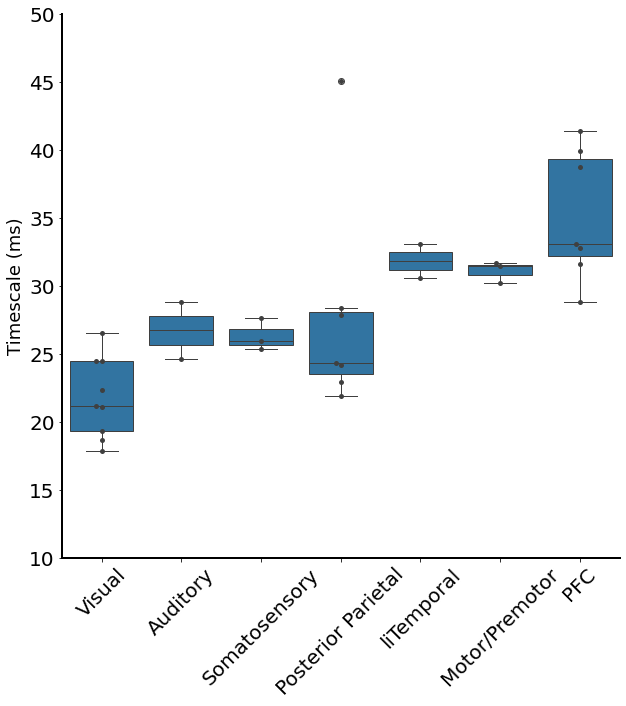

In [29]:
# hue_order = ['Visual', 'Posterior Parietal', 'liTemporal', 'Auditory', 
#        'Somatosensory', 'Motor/Premotor', 'PFC']

hue_order = ['Visual', 'Auditory', 'Somatosensory', 'Posterior Parietal', 'liTemporal',  'Motor/Premotor', 'PFC']

# region_exp = np.array(region_exp)
for area_k in ['dLPFC', 'mPFC', 'vLPFC']:
    region[region == area_k] = 'PFC'
df_exp = pd.DataFrame()
df_exp['Region'] = region
df_exp['tau'] = tau_lst_exp
fig10, ax = plt.subplots(figsize=(15,10), facecolor=(1, 1, 1))
sns.boxplot(x="Region", y="tau", data=df_exp, order=hue_order)
sns.swarmplot(x="Region", y="tau", data=df_exp, order=hue_order, color=".25")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Timescale (ms)', fontsize=18)
plt.xlabel('')
plt.ylim([10, 50])
# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make the bottom and left spines thicker
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

ax.set_xticks(np.arange(len(hue_order)))
ax.set_xticklabels(hue_order,rotation=45,fontsize=20)

fig10.set_figwidth(10)
# TCP.save_fig('Figures/1D_Supp')

## Awake

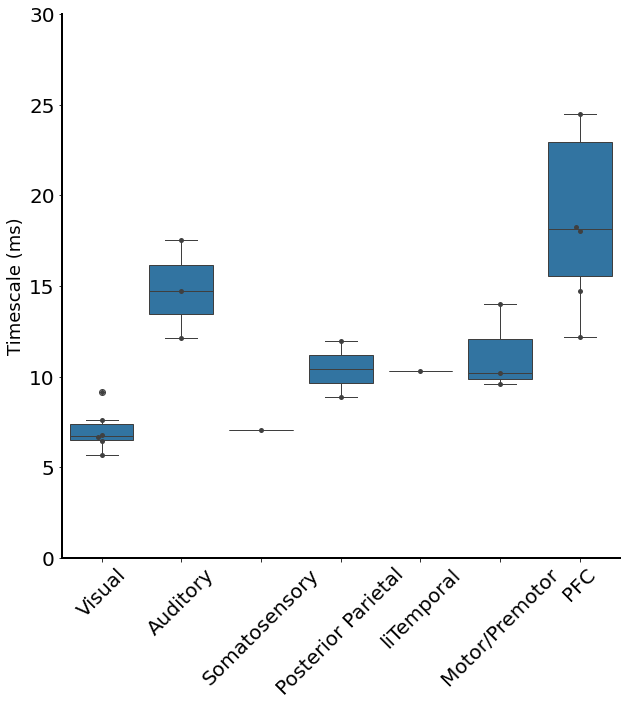

In [30]:
# hue_order = ['Visual', 'Posterior Parietal', 'liTemporal', 'Auditory', 
#        'Somatosensory', 'Motor/Premotor', 'PFC']

hue_order = ['Visual', 'Auditory', 'Somatosensory', 'Posterior Parietal', 'liTemporal',  'Motor/Premotor', 'PFC']

# region_exp = np.array(region_exp)
for area_k in ['dLPFC', 'mPFC', 'vLPFC']:
    region_awake[region_awake == area_k] = 'PFC'
df_exp = pd.DataFrame()
df_exp['Region'] = region_awake
df_exp['tau'] = tau_lst_exp_awake
fig10, ax = plt.subplots(figsize=(15,10), facecolor=(1, 1, 1))
sns.boxplot(x="Region", y="tau", data=df_exp, order=hue_order)
sns.swarmplot(x="Region", y="tau", data=df_exp, order=hue_order, color=".25")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Timescale (ms)', fontsize=18)
plt.xlabel('')
plt.ylim([0, 30])
# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make the bottom and left spines thicker
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

ax.set_xticks(np.arange(len(hue_order)))
ax.set_xticklabels(hue_order,rotation=45,fontsize=20)

fig10.set_figwidth(10)
# TCP.save_fig('Figures/1D_Supp_awake')